In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

import os
os.makedirs("reports/figures", exist_ok=True)

In [4]:
#Load Datasets

df = pd.read_csv("../data/raw/aps_failure_training_set.csv")

print(df.shape)

df.head()

(60000, 171)


,class,aa_000,ab_000,ac_000,ad_000,ae_000,af_000,ag_000,ag_001,ag_002,...,ee_002,ee_003,ee_004,ee_005,ee_006,ee_007,ee_008,ee_009,ef_000,eg_000
0,0,76698,na,2130706438,280,0,0,0,0,0,...,1240520,493384,721044,469792,339156,157956,73224,0,0,0
1,0,33058,na,0,na,0,0,0,0,0,...,421400,178064,293306,245416,133654,81140,97576,1500,0,0
2,0,41040,na,228,100,0,0,0,0,0,...,277378,159812,423992,409564,320746,158022,95128,514,0,0
3,0,12,0,70,66,0,10,0,0,0,...,240,46,58,44,10,0,0,0,4,32
4,0,60874,na,1368,458,0,0,0,0,0,...,622012,229790,405298,347188,286954,311560,433954,1218,0,0


In [5]:
# Dataset Information

print("="*80)
print("Dataset Information")
print("="*80)

print(df.info())

print("\n")

print(df.describe(include='all').T)

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Columns: 171 entries, class to eg_000
dtypes: int64(2), object(169)
memory usage: 78.3+ MB
None


          count unique  top   freq          mean            std  min    25%  \
class   60000.0    NaN  NaN    NaN      0.016667        0.12802  0.0    0.0   
aa_000  60000.0    NaN  NaN    NaN  59336.499567  145430.056532  0.0  834.0   
ab_000    60000     30   na  46329           NaN            NaN  NaN    NaN   
ac_000    60000   2062    0   8752           NaN            NaN  NaN    NaN   
ad_000    60000   1887   na  14861           NaN            NaN  NaN    NaN   
...         ...    ...  ...    ...           ...            ...  ...    ...   
ee_007    60000  30470    0   7898           NaN            NaN  NaN    NaN   
ee_008    60000  24214    0  17280           NaN            NaN  NaN    NaN   
ee_009    60000   9725    0  31863           NaN            NaN  NaN    NaN   
ef_000    60000 

In [6]:
# Convert Missing Values

df.replace("na", np.nan, inplace=True)

print(df.isnull().sum().sum(), "Missing values")

850015 Missing values


In [7]:
# Convert Features to Numeric

target = df["class"]

X = df.drop("class", axis=1)

X = X.apply(pd.to_numeric)

df = pd.concat([X, target], axis=1)

In [8]:
# Target Encoding

df["class"] = df["class"].map({
    "neg":0,
    "pos":1
})

In [9]:
# Dataset Shape

print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 60000
Columns : 171


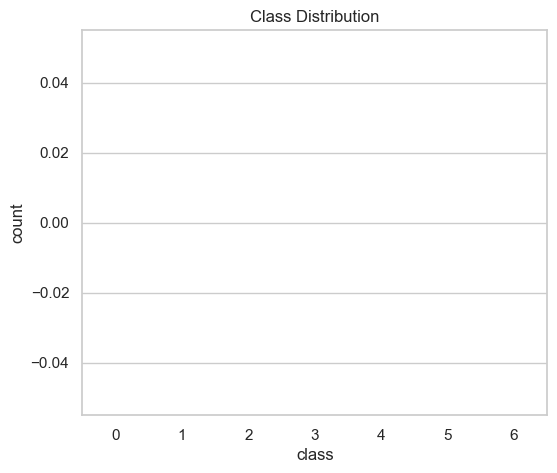

Series([], Name: count, dtype: int64)
Series([], Name: proportion, dtype: float64)


In [10]:
# Class Distribution

plt.figure(figsize=(6,5))

sns.countplot(x="class", data=df)

plt.title("Class Distribution")

plt.savefig("reports/figures/class_distribution.png",
            dpi=300,
            bbox_inches='tight')

plt.show()

print(df["class"].value_counts())

print(df["class"].value_counts(normalize=True)*100)

In [11]:
# Summary Statistics

summary = df.describe().T

summary.to_csv("reports/tables_summary_statistics.csv")

summary.head()

,count,mean,std,min,25%,50%,75%,max
aa_000,60000.0,5.933650e+04,1.454301e+05,0.0,834.0,30776.0,48668.0,2.746564e+06
ab_000,13671.0,7.131885e-01,3.478962e+00,0.0,0.0,0.0,0.0,2.040000e+02
ac_000,56665.0,3.560143e+08,7.948749e+08,0.0,16.0,152.0,964.0,2.130707e+09
ad_000,45139.0,1.906206e+05,4.040441e+07,0.0,24.0,126.0,430.0,8.584298e+09
ae_000,57500.0,6.819130e+00,1.615434e+02,0.0,0.0,0.0,0.0,2.105000e+04


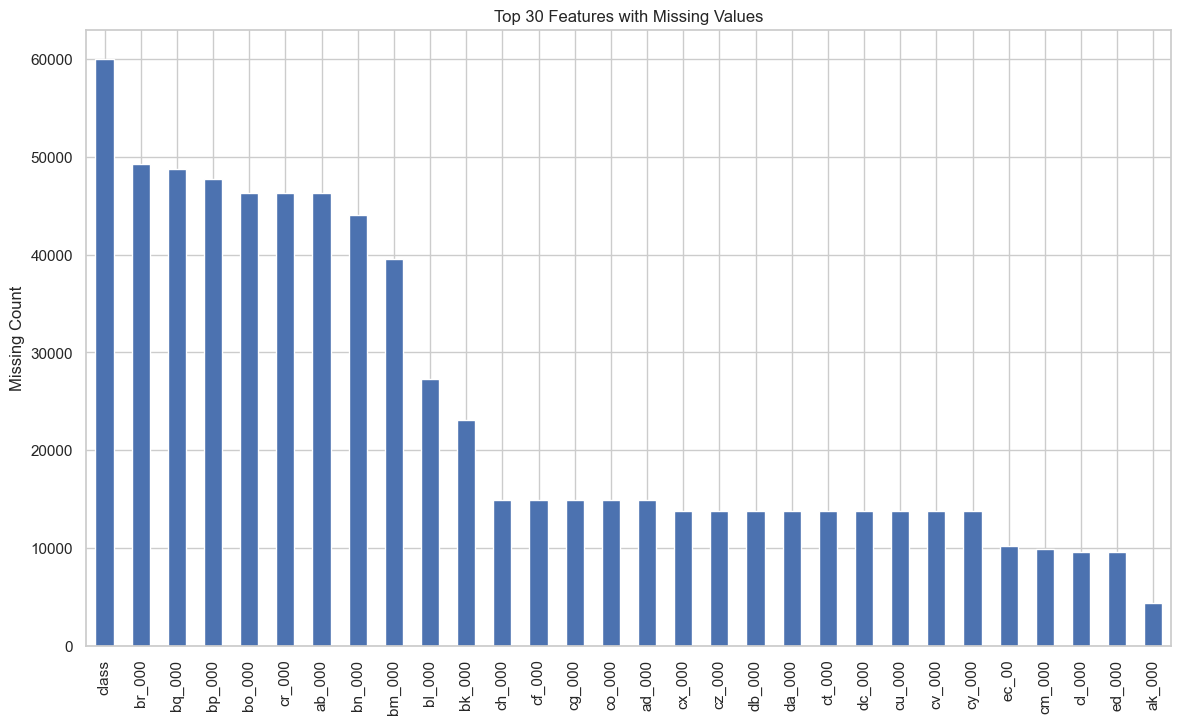

In [12]:
# Missing Value Analysis

missing = df.isnull().sum()

missing = missing[missing>0]

missing = missing.sort_values(ascending=False)

plt.figure(figsize=(14,8))

missing.head(30).plot(kind='bar')

plt.title("Top 30 Features with Missing Values")

plt.ylabel("Missing Count")

plt.savefig("reports/figures/missing_values.png",
            dpi=300,
            bbox_inches='tight')

plt.show()


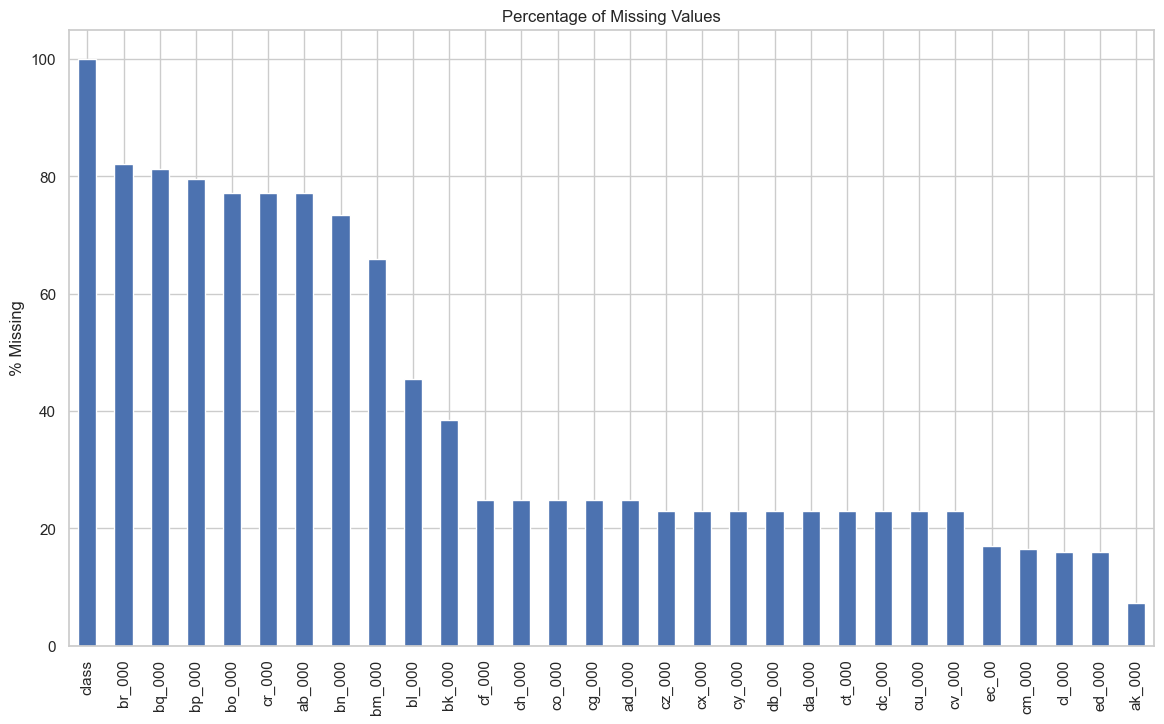

In [13]:
# Missing Percentage

missing_percent = df.isnull().mean()*100

missing_percent = missing_percent.sort_values(
    ascending=False
)

plt.figure(figsize=(14,8))

missing_percent.head(30).plot(kind='bar')

plt.ylabel("% Missing")

plt.title("Percentage of Missing Values")

plt.savefig("reports/figures/missing_percentage.png",
            dpi=300)

plt.show()

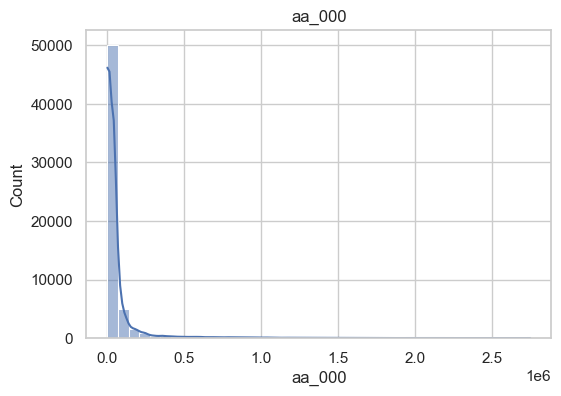

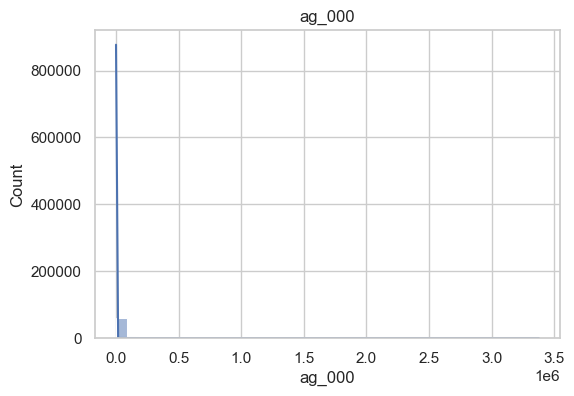

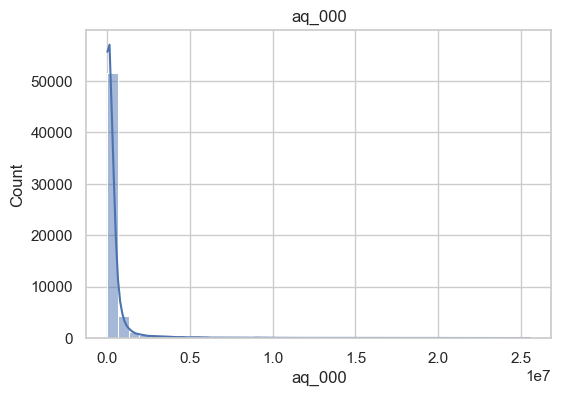

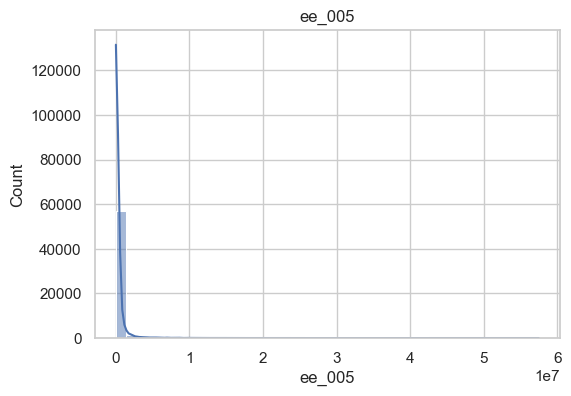

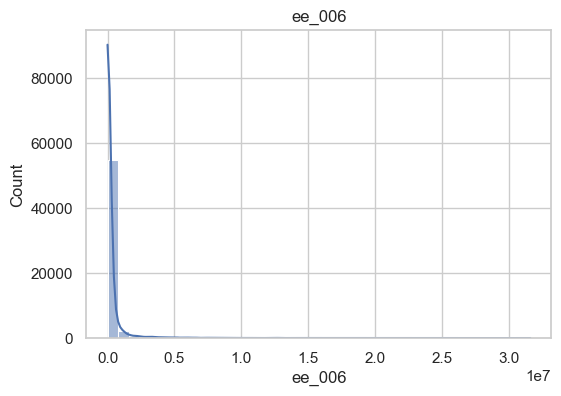

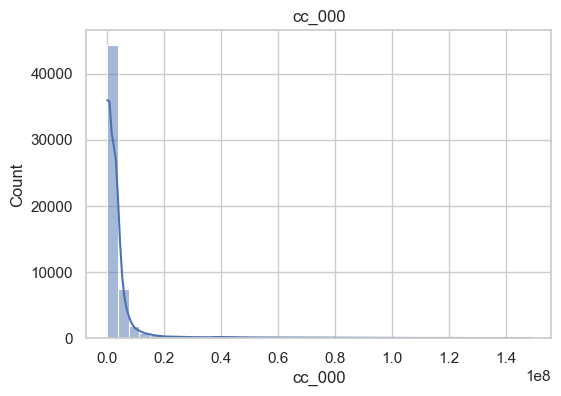

In [14]:
# Choose several representative sensors

features = [
    'aa_000',
    'ag_000',
    'aq_000',
    'ee_005',
    'ee_006',
    'cc_000'
]

for col in features:

    plt.figure(figsize=(6,4))

    sns.histplot(df[col],
                 bins=40,
                 kde=True)

    plt.title(col)

    plt.savefig(
        f"reports/figures/{col}_hist.png",
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()

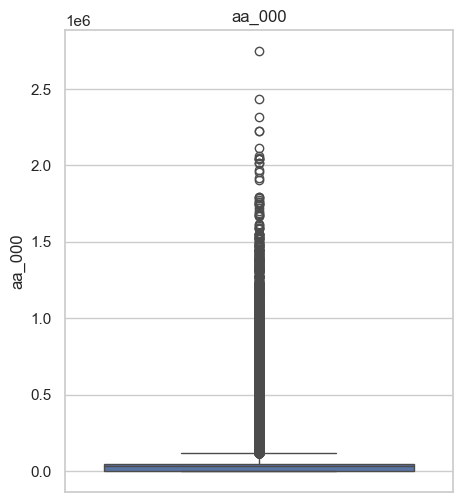

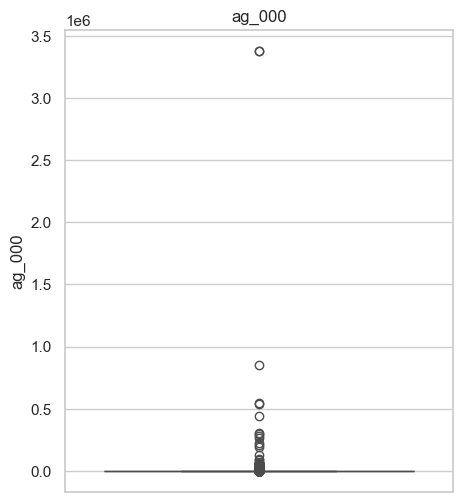

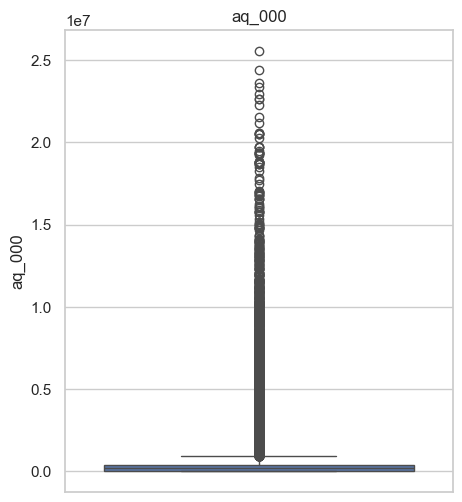

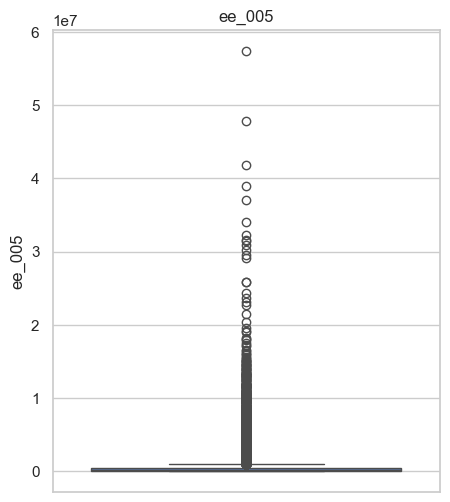

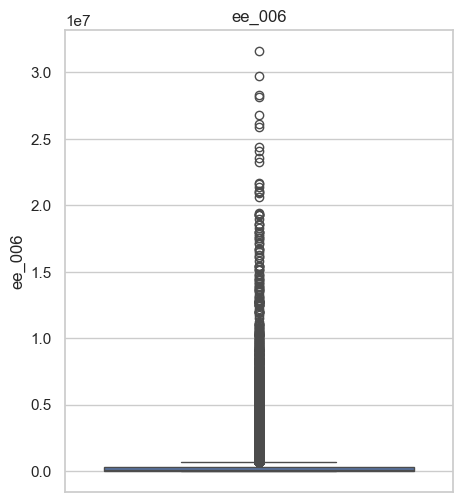

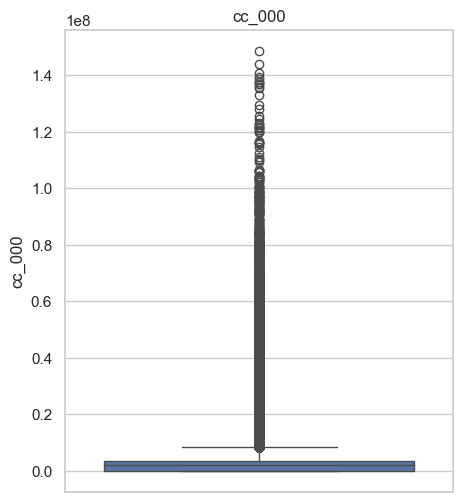

In [15]:
# Find Outliers

for col in features:

    plt.figure(figsize=(5,6))

    sns.boxplot(y=df[col])

    plt.title(col)

    plt.savefig(
        f"reports/figures/{col}_boxplot.png",
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()


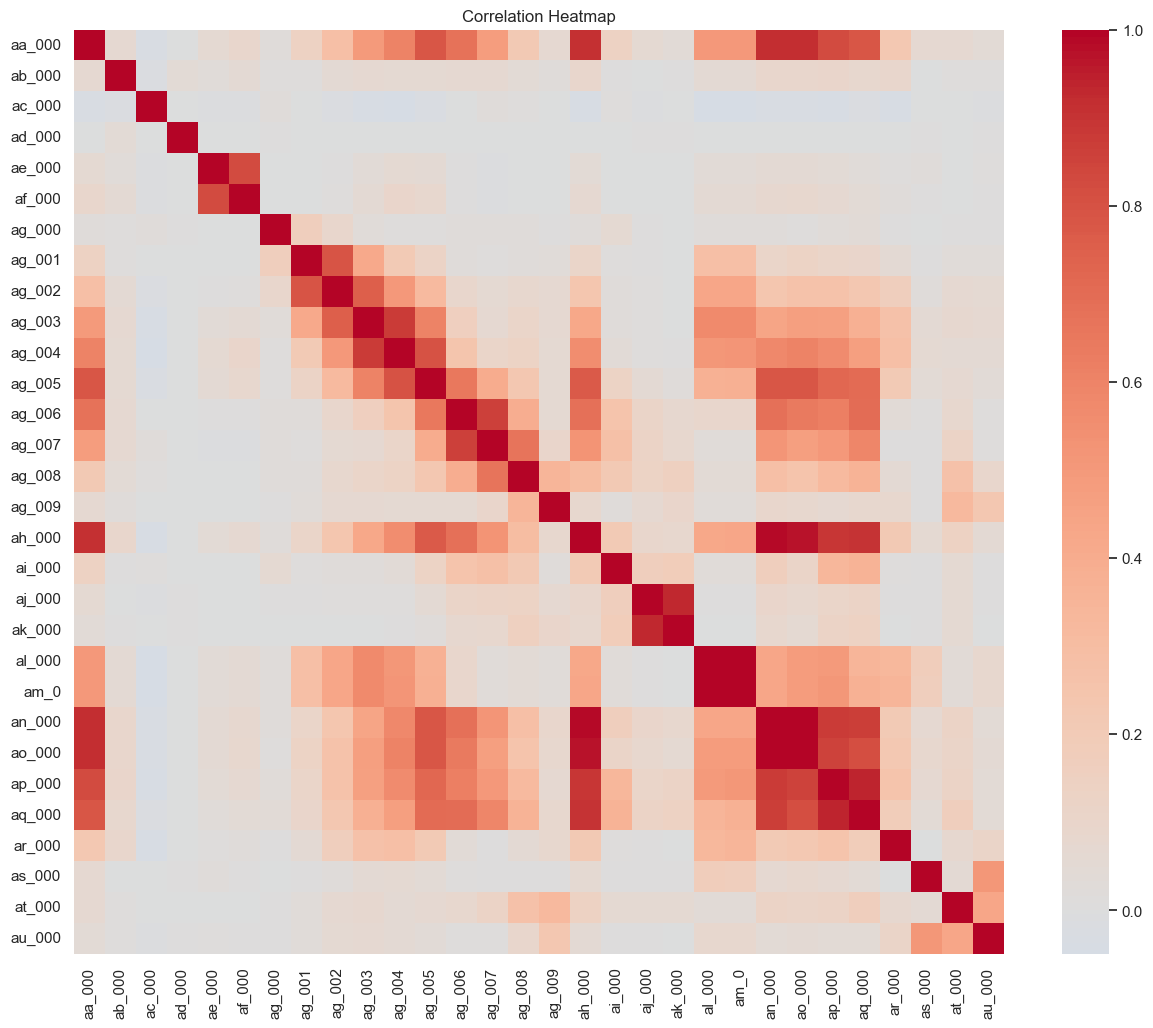

In [16]:
# Correlation Analysis

corr = df.corr(numeric_only=True)

plt.figure(figsize=(15,12))

sns.heatmap(
    corr.iloc[:30,:30],
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")

plt.savefig(
    "reports/figures/correlation_heatmap.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

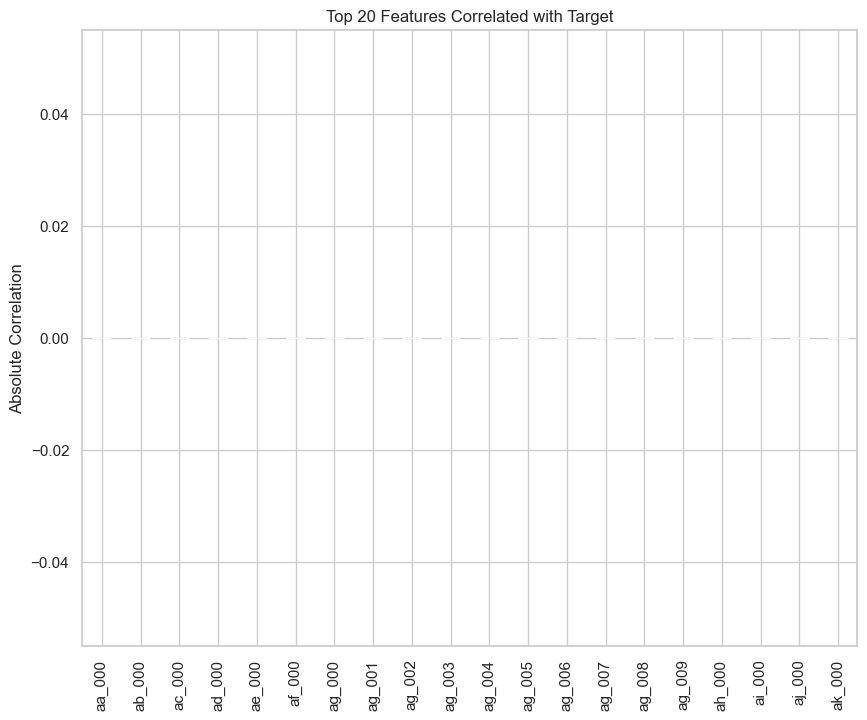

In [17]:
# Correlation with Target

target_corr = corr["class"]

target_corr = target_corr.drop("class")

target_corr = target_corr.abs()

target_corr = target_corr.sort_values(
    ascending=False
)

plt.figure(figsize=(10,8))

target_corr.head(20).plot(kind='bar')

plt.title("Top 20 Features Correlated with Target")

plt.ylabel("Absolute Correlation")

plt.savefig(
    "reports/figures/top_correlations.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

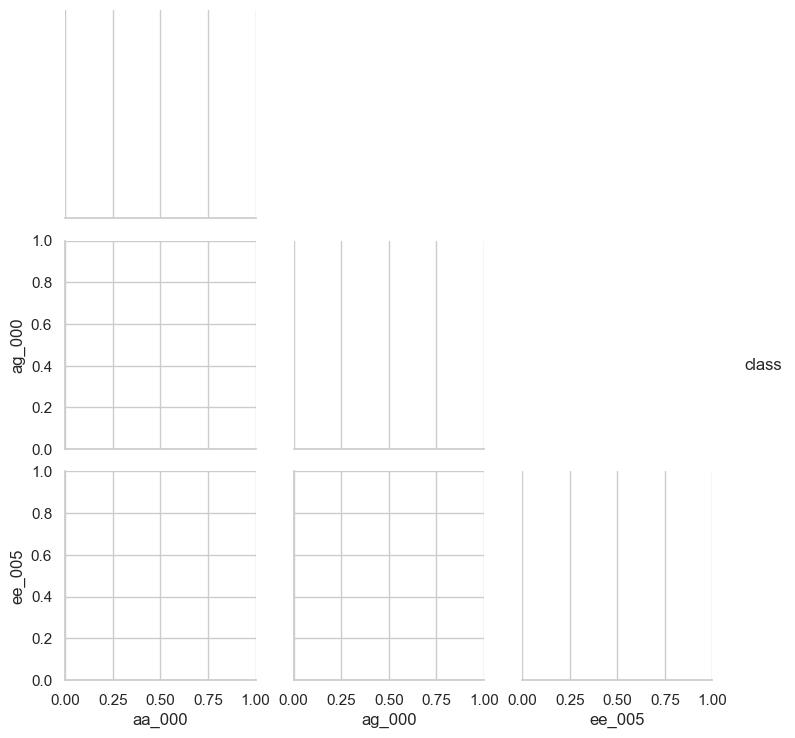

In [18]:
pair_df = df[
    [
        'aa_000',
        'ag_000',
        'ee_005',
        'class'
    ]
].dropna()

sns.pairplot(
    pair_df,
    hue='class',
    corner=True
)

plt.savefig(
    "reports/figures/pairplot.png",
    dpi=300
)

plt.show()

In [19]:
# Skewness

skew = df.skew(numeric_only=True)

skew = skew.sort_values(
    ascending=False
)

print(skew.head(20))

cs_009    243.531177
cf_000    212.459407
co_000    212.459406
ad_000    212.459406
dh_000    202.907014
az_009    163.609146
ay_009    159.066837
ag_000    153.387555
dj_000    150.507647
cs_007    140.732294
cs_008    121.563916
ak_000    113.625497
as_000    111.732428
au_000    108.987809
df_000    108.938646
ct_000    107.031061
ay_001    102.415758
cn_009    101.075836
ag_009     98.288989
dz_000     92.410273
dtype: float64


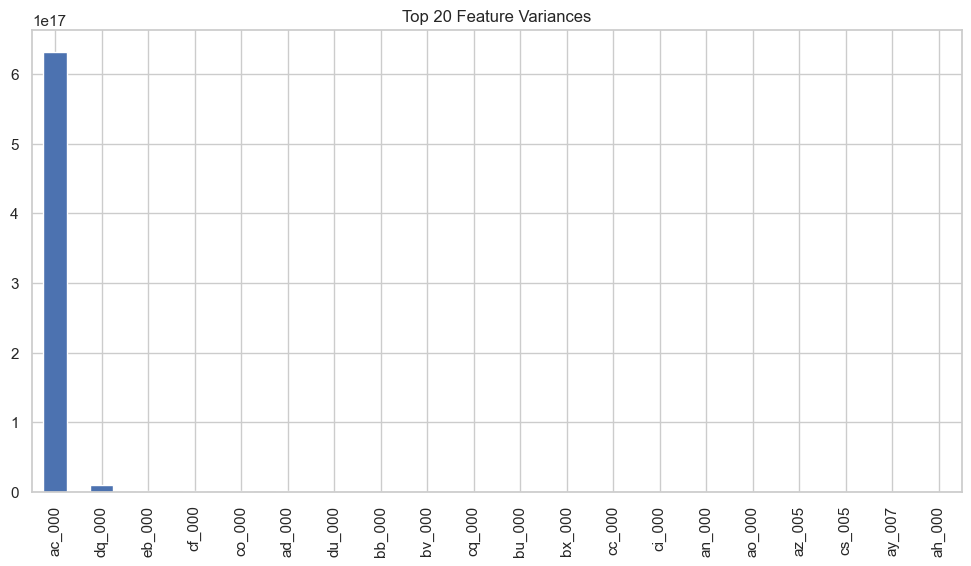

In [20]:
# Variance

variance = df.drop(
    "class",
    axis=1
).var()

variance = variance.sort_values(
    ascending=False
)

plt.figure(figsize=(12,6))

variance.head(20).plot(kind='bar')

plt.title("Top 20 Feature Variances")

plt.savefig(
    "reports/figures/feature_variance.png",
    dpi=300
)

plt.show()

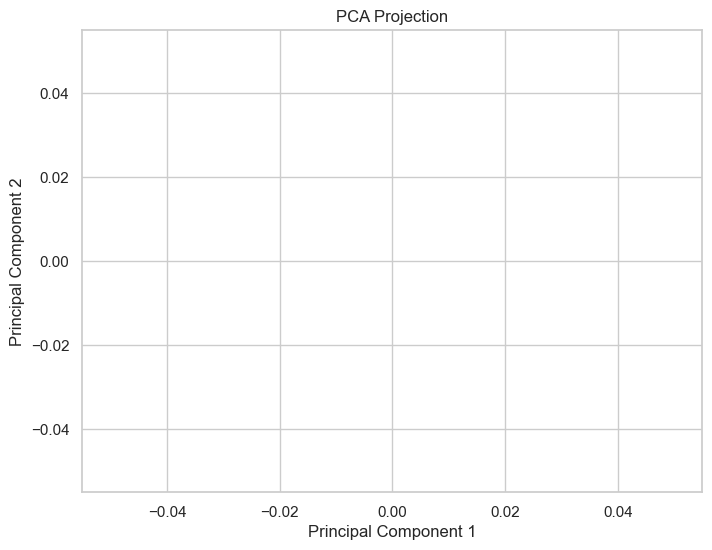

In [21]:
# PCA Visualization

# mpute missing values first
X = df.drop("class", axis=1)

X = X.fillna(
    X.median()
)

# Standardize
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

#Visualize PCA
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=df["class"],
    cmap="coolwarm",
    alpha=0.5
)

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.title("PCA Projection")

plt.savefig(
    "reports/figures/pca_projection.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

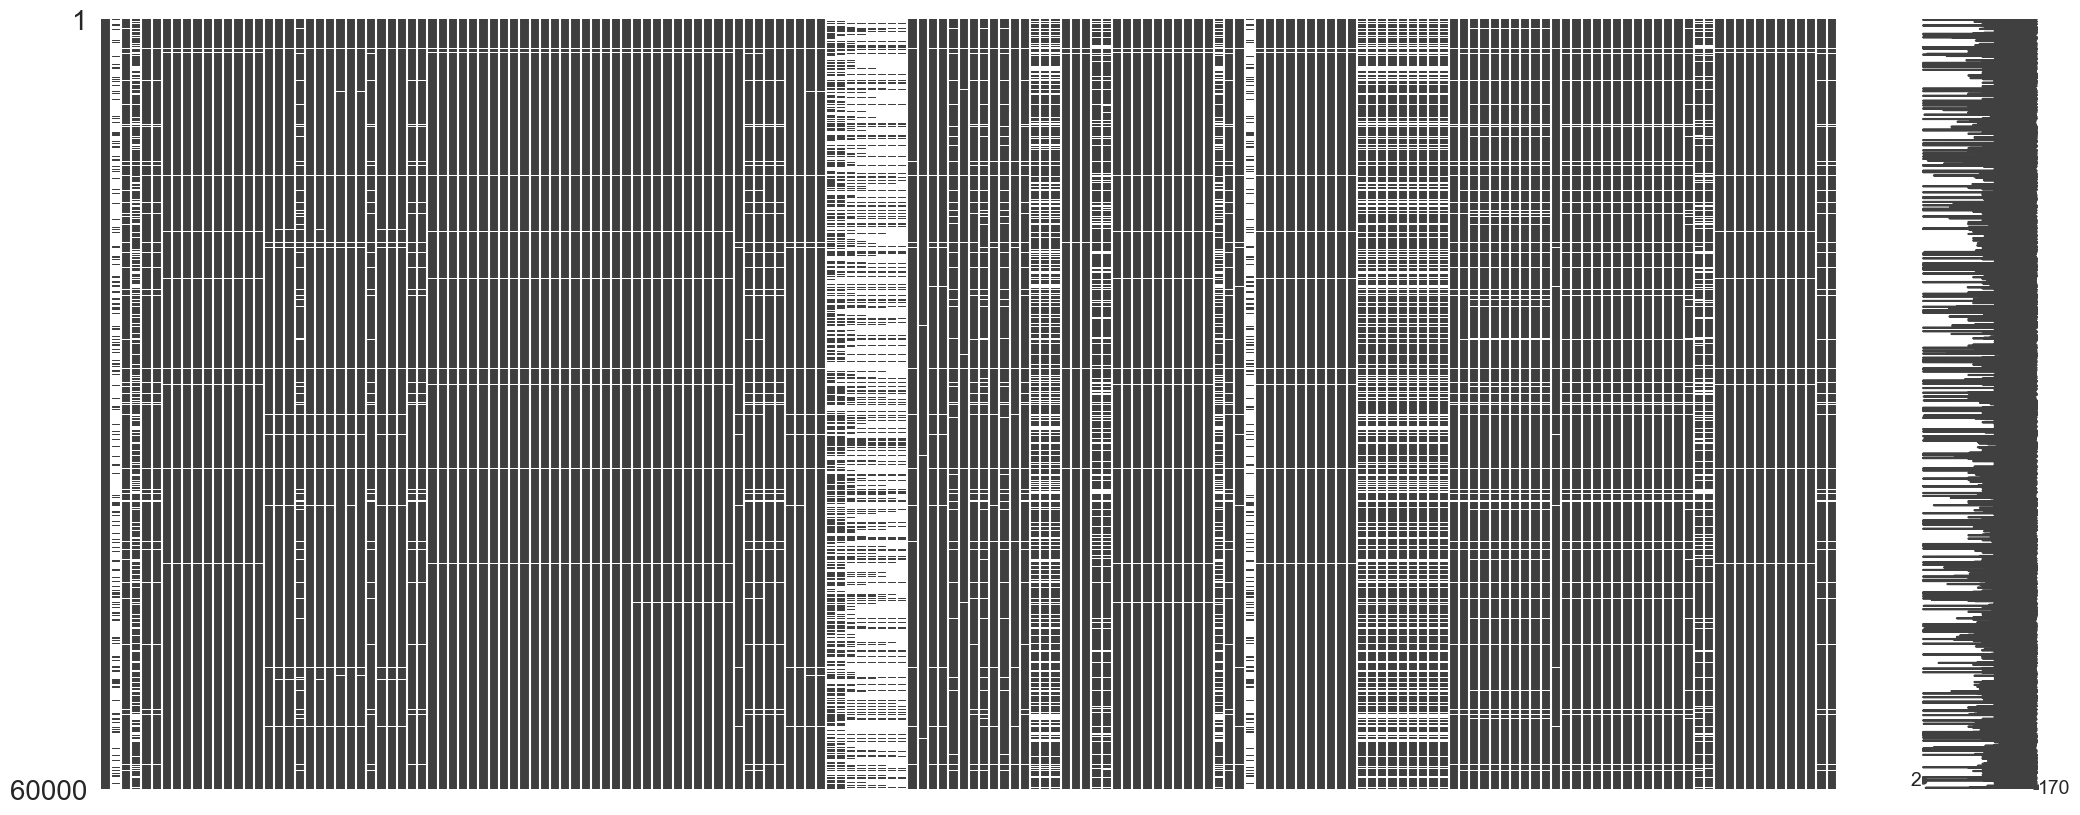

In [22]:
# Missing Value Matrix

import missingno as msno

msno.matrix(df)

plt.savefig(
    "reports/figures/missing_matrix.png",
    dpi=300
)

plt.show()

In [23]:
# Duplicate Records
duplicates = df.duplicated().sum()

print("Duplicate Rows :", duplicates)

Duplicate Rows : 0


In [26]:
# Save Cleaned Dataset
df.to_csv(
    "../data/interim/cleaned_train.csv",
    index=False
)